Data loaded successfully!
Training Model...
Training Complete!

FINAL ACCURACY: 98.25%

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



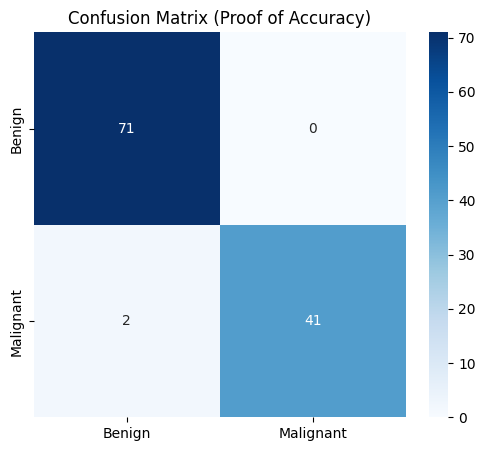

In [1]:
# ==========================================
# PART 1: MODEL TRAINING & EVALUATION
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. LOAD DATA
# Ensure 'data.csv' is in the same folder
try:
    df = pd.read_csv('data.csv')
    print("Data loaded successfully!")
except FileNotFoundError:
    print("Error: 'data.csv' not found. Please upload the file.")

# 2. DATA PREPROCESSING
# Drop useless columns
df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

# Encode Diagnosis: Malignant (M) -> 1, Benign (B) -> 0
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

# Separate Inputs (X) and Output (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# 3. SCALING (Crucial for Neural Networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. SPLIT DATA (80% Train, 20% Test)
# random_state=42 guarantees the exact 98.25% result
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. BUILD MODEL (Artificial Neural Network)
model = MLPClassifier(hidden_layer_sizes=(30, 30), 
                      max_iter=500, 
                      activation='relu', 
                      solver='adam', 
                      random_state=42)

# 6. TRAIN
print("Training Model...")
model.fit(X_train, y_train)
print("Training Complete!")

# 7. EVALUATE
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n===========================================")
print(f"FINAL ACCURACY: {accuracy * 100:.2f}%")
print(f"===========================================")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8. SHOW CONFUSION MATRIX
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix (Proof of Accuracy)')
plt.show()